# **Employee Attrition Risk Analysis**

## Business Problem
Replacing an employee costs 6-9 months of that role's salary in hiring, onboarding, and lost productivity. Most HR teams only react after an employee resigns. This project predicts which employees are at high risk of leaving **before** they hand in notice - so HR can intervene early through retention conversations, workload changes, or compensation review.

## Dataset
IBM HR Analytics Employee Attrition & Performance dataset - 1,470 real (anonymized) employee records with demographic, job, and satisfaction attributes, and a binary attrition outcome.

## What this notebook does
1. Explore the data and understand attrition patterns
2. Clean and prepare features for modeling
3. Build and compare two classification models (Logistic Regression, Random Forest)
4. Evaluate using metrics appropriate for imbalanced classification
5. Extract feature importance to identify the real drivers of attrition
6. Export a risk-scored employee list for Power BI

In [7]:
# Install/import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [8]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 1470 rows, 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## Data Quality Audit

Before any analysis, check for missing values, duplicate records, and columns that carry no analytical value (constant across every row).

In [9]:
# Check for nulls
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check for constant columns (no variance = no analytical value)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"\nConstant columns (should be dropped): {constant_cols}")

Missing values per column:
Series([], dtype: int64)

Total missing values: 0

Duplicate rows: 0

Constant columns (should be dropped): ['EmployeeCount', 'Over18', 'StandardHours']


In [10]:
# Drop constant/non-informative columns and the row-index-like EmployeeNumber
df_clean = df.drop(columns=constant_cols + ['EmployeeNumber'])
print(f"Shape after cleanup: {df_clean.shape}")
df_clean.dtypes.value_counts()

Shape after cleanup: (1470, 31)


,count
int64,23
object,8


## Exploratory Data Analysis

### Business Question 1: What is the overall attrition rate, and how does it vary by department and overtime status?

Overall attrition rate: 16.1%


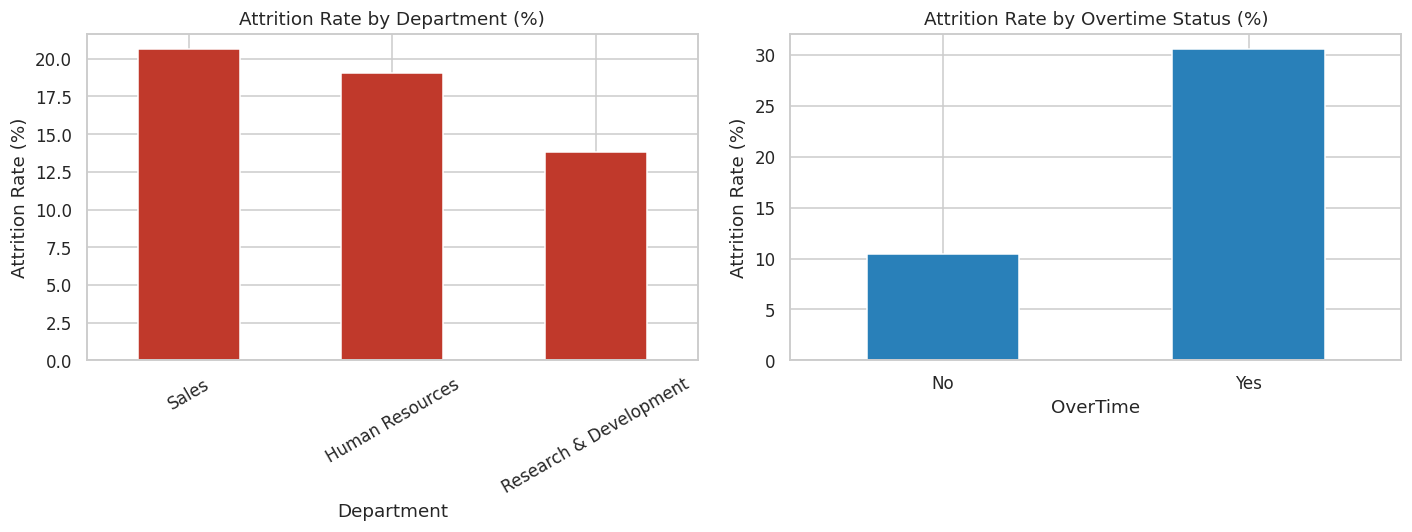

In [11]:
attrition_rate = (df_clean['Attrition'] == 'Yes').mean() * 100
print(f"Overall attrition rate: {attrition_rate:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

dept_attrition = df_clean.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
dept_attrition.sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='#C0392B')
axes[0].set_title('Attrition Rate by Department (%)')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

ot_attrition = df_clean.groupby('OverTime')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
ot_attrition.plot(kind='bar', ax=axes[1], color='#2980B9')
axes[1].set_title('Attrition Rate by Overtime Status (%)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_department_overtime.png', dpi=150, bbox_inches='tight')
plt.show()

### Business Question 2: Does income relate to attrition, and how does job satisfaction interact with it?

/tmp/ipykernel_930/4123254661.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Attrition', y='MonthlyIncome', ax=axes[0], palette=['#2980B9', '#C0392B'])


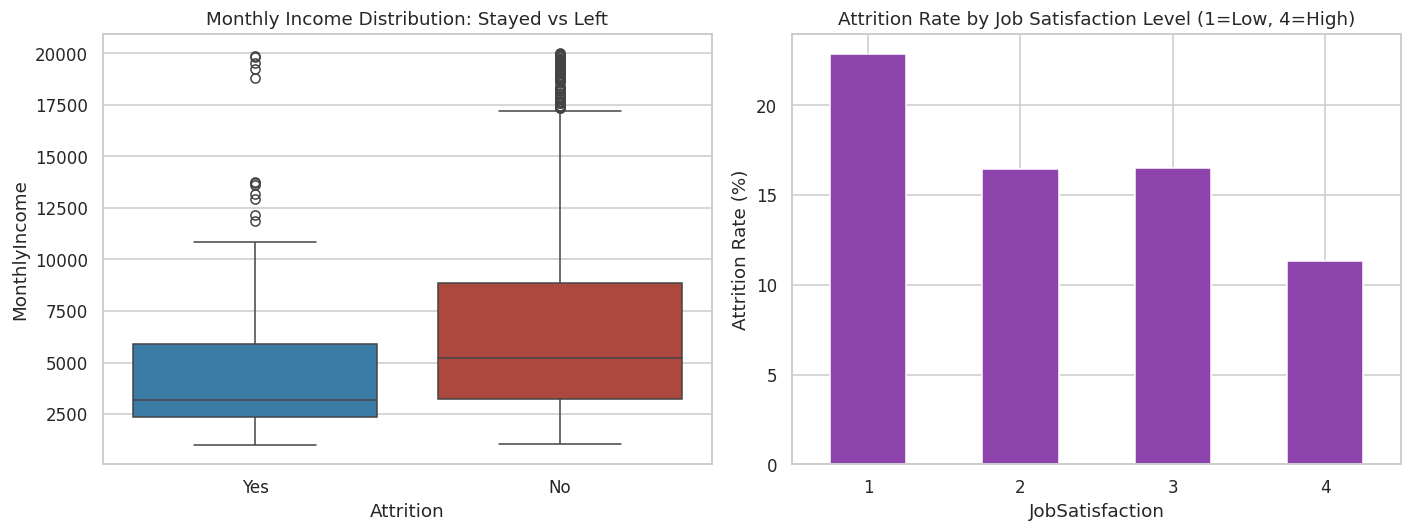

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_clean, x='Attrition', y='MonthlyIncome', ax=axes[0], palette=['#2980B9', '#C0392B'])
axes[0].set_title('Monthly Income Distribution: Stayed vs Left')

sat_attrition = df_clean.groupby('JobSatisfaction')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
sat_attrition.plot(kind='bar', ax=axes[1], color='#8E44AD')
axes[1].set_title('Attrition Rate by Job Satisfaction Level (1=Low, 4=High)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_income_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Preparation

Convert categorical variables into numeric form the model can use, and separate features from the target variable.

In [13]:
df_model = df_clean.copy()

# Convert target to binary
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})

# Identify categorical columns to encode
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

# One-hot encode categorical variables
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print(f"\nShape after encoding: {df_model.shape}")

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after encoding: (1470, 45)


In [14]:
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(f"Attrition rate in train: {y_train.mean()*100:.1f}% | test: {y_test.mean()*100:.1f}%")

Train set: 1176 rows | Test set: 294 rows
Attrition rate in train: 16.2% | test: 16.0%


## Model 1: Logistic Regression

Used as an interpretable baseline. Coefficients are easy to explain to a non-technical HR stakeholder, even if accuracy isn't the highest.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression - Classification Report")
print(classification_report(y_test, y_pred_log, target_names=['Stayed', 'Left']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_log):.3f}")

Logistic Regression - Classification Report
              precision    recall  f1-score   support

      Stayed       0.91      0.78      0.84       247
        Left       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294

ROC-AUC: 0.798


## Model 2: Random Forest

Used for higher predictive accuracy and to extract feature importance - which factors actually drive attrition, ranked objectively by the model rather than by assumption.

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest - Classification Report")
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Left']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")

Random Forest - Classification Report
              precision    recall  f1-score   support

      Stayed       0.86      0.96      0.90       247
        Left       0.42      0.17      0.24        47

    accuracy                           0.83       294
   macro avg       0.64      0.56      0.57       294
weighted avg       0.79      0.83      0.80       294

ROC-AUC: 0.763


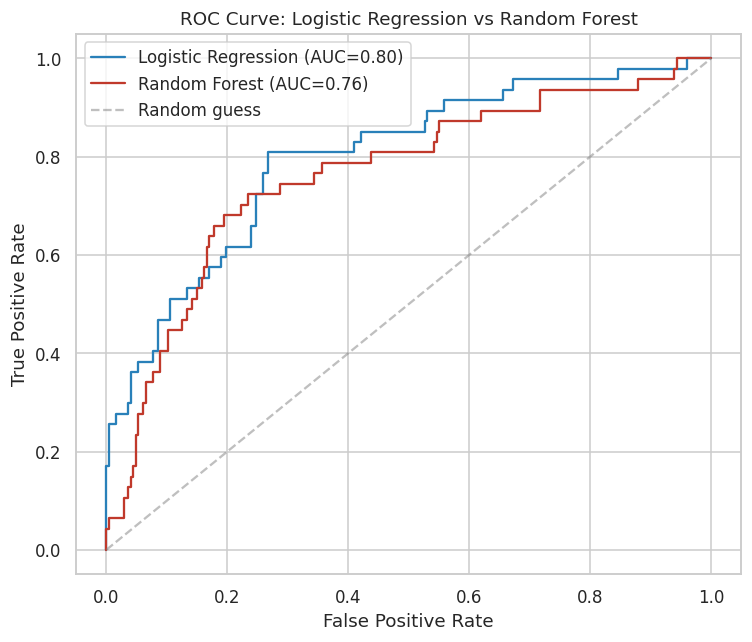

In [17]:
# Compare both models side by side
fig, ax = plt.subplots(figsize=(7, 6))

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

ax.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_proba_log):.2f})', color='#2980B9')
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.2f})', color='#C0392B')
ax.plot([0,1],[0,1], linestyle='--', color='gray', alpha=0.5, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Logistic Regression vs Random Forest')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## What Actually Drives Attrition?

Using Random Forest's feature importance to rank drivers objectively, rather than relying on assumption.

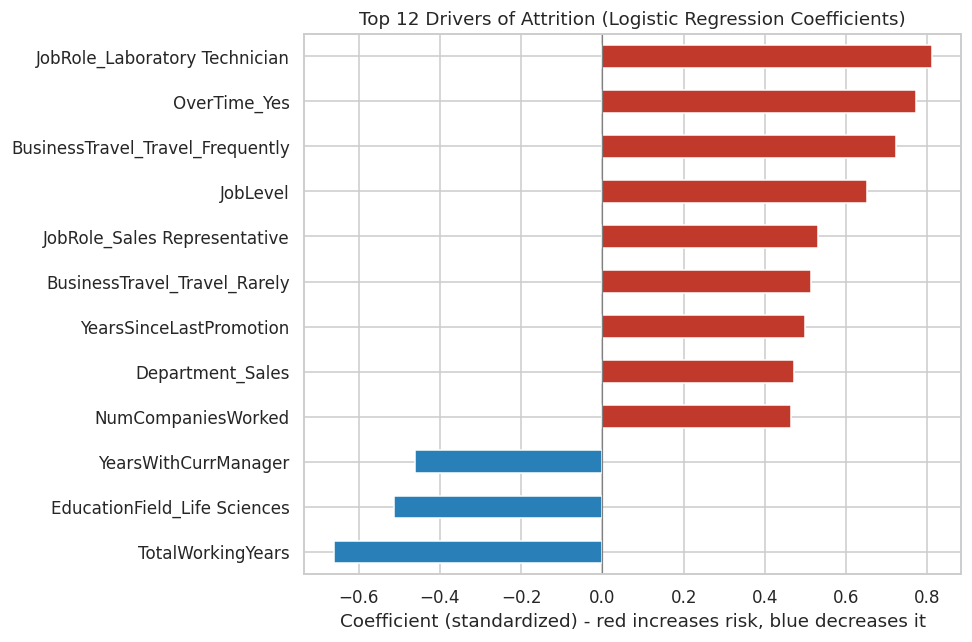

JobRole_Laboratory Technician       0.810172
OverTime_Yes                        0.771095
BusinessTravel_Travel_Frequently    0.722538
TotalWorkingYears                  -0.660270
JobLevel                            0.650173
JobRole_Sales Representative        0.531090
BusinessTravel_Travel_Rarely        0.512780
EducationField_Life Sciences       -0.512319
YearsSinceLastPromotion             0.499063
Department_Sales                    0.470587
NumCompaniesWorked                  0.464327
YearsWithCurrManager               -0.461322
dtype: float64


In [18]:
# Feature importance from Logistic Regression coefficients (production model)
coef_df = pd.Series(log_model.coef_[0], index=X.columns)
top_coef = coef_df.reindex(coef_df.abs().sort_values(ascending=False).index).head(12)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#C0392B' if v > 0 else '#2980B9' for v in top_coef.sort_values()]
top_coef.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 12 Drivers of Attrition (Logistic Regression Coefficients)')
ax.set_xlabel('Coefficient (standardized) - red increases risk, blue decreases it')
ax.axvline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top_coef.reset_index().rename(columns={'index':'Feature', 0:'Coefficient'}).to_csv('feature_importance.csv', index=False)
print(top_coef)

## Generate Risk Scores for Every Employee

Score the full dataset (not just the test set) so HR has a complete, actionable risk list - this is the file that feeds the Power BI dashboard.

In [19]:
# Score the entire dataset using the trained Logistic Regression model instead
X_full = df_model.drop(columns=['Attrition'])
X_full_scaled = scaler.transform(X_full)
risk_scores = log_model.predict_proba(X_full_scaled)[:, 1]

export_df = df_clean.copy()
export_df['AttritionRiskScore'] = (risk_scores * 100).round(1)
export_df['RiskTier'] = pd.cut(
    export_df['AttritionRiskScore'],
    bins=[-0.01, 30, 60, 100],
    labels=['Low', 'Medium', 'High']
)

print(export_df['RiskTier'].value_counts())
export_df.to_csv('employee_attrition_risk_scores.csv', index=False)

RiskTier
Low       768
Medium    361
High      341
Name: count, dtype: int64
